## merge data

In [22]:
import pandas as pd

In [23]:
df1=pd.DataFrame({
    "customerid":[1,2,3,4],
    "name":["ahmed","ali","omar","aya"],
    "courses":["ai","ml","ai","ui"]
})

In [24]:
df2=pd.DataFrame({
    "customerid":[2,3,4,5],
    "purchase":["lab","phone","tap","monitor"],
    "courses":["ml","ai","ui","web"]
})

In [25]:
df1

,customerid,name,courses
0,1,ahmed,ai
1,2,ali,ml
2,3,omar,ai
3,4,aya,ui


In [26]:
df2

,customerid,purchase,courses
0,2,lab,ml
1,3,phone,ai
2,4,tap,ui
3,5,monitor,web


# inner

In [27]:
inner_join=pd.merge(df1,df2,how="inner",on=['customerid','courses'])

In [28]:
inner_join

,customerid,name,courses,purchase
0,2,ali,ml,lab
1,3,omar,ai,phone
2,4,aya,ui,tap


In [29]:
inner_join=pd.merge(df1,df2,how="right",on=['customerid','courses'])

In [30]:
inner_join

,customerid,name,courses,purchase
0,2,ali,ml,lab
1,3,omar,ai,phone
2,4,aya,ui,tap
3,5,NaN,web,monitor


In [31]:
inner_join=pd.merge(df1,df2,how="left",on=['customerid','courses'])

In [32]:
inner_join

,customerid,name,courses,purchase
0,1,ahmed,ai,NaN
1,2,ali,ml,lab
2,3,omar,ai,phone
3,4,aya,ui,tap


In [33]:
inner_join=pd.merge(df1,df2,how="outer",on=['customerid','courses'])#full

In [34]:
inner_join

,customerid,name,courses,purchase
0,1,ahmed,ai,NaN
1,2,ali,ml,lab
2,3,omar,ai,phone
3,4,aya,ui,tap
4,5,NaN,web,monitor


# handle missing values

In [35]:
data=pd.DataFrame({"age":[21,30,None,69,65,None,35],
                  " BLOOD_PRESS":[120,130,110,None,80,145,None],
                   "colestrol":[210,None,300,210,None,200,400]
                  })

                   
                   

In [36]:
data


,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,NaN,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,NaN
5,NaN,145.0,200.0
6,35.0,NaN,400.0


# handle missing valyes

In [37]:
data_copy=data

In [38]:
data_copy

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,NaN,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,NaN
5,NaN,145.0,200.0
6,35.0,NaN,400.0


In [39]:
data.isnull().sum()

age             2
 BLOOD_PRESS    2
colestrol       2
dtype: int64

In [40]:
data_copy=data_copy.dropna()#remove rows null

In [41]:
data_copy

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0


In [42]:
data_drop_col=data.dropna(subset=['colestrol'])#determine column

In [43]:
data_drop_col

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
2,NaN,110.0,300.0
3,69.0,NaN,210.0
5,NaN,145.0,200.0
6,35.0,NaN,400.0


# imputation

In [44]:
data=pd.DataFrame({"age":[21,30,None,69,65,None,35],
                  "BLOOD_PRESS":[120,130,110,None,80,145,None],
                   "colestrol":[210,None,300,210,None,200,400]
                  })


In [45]:
data.age.mean()

np.float64(44.0)

In [46]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
data.age.fillna(data.age.mean(),inplace=True)

In [48]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,44.0,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,NaN
5,44.0,145.0,200.0
6,35.0,NaN,400.0


In [49]:
data.isnull().sum()

age            0
BLOOD_PRESS    2
colestrol      2
dtype: int64

In [50]:
data.colestrol.fillna(data.colestrol.mean(),inplace=True)

In [51]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,264.0
2,44.0,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,264.0
5,44.0,145.0,200.0
6,35.0,NaN,400.0


In [52]:
data.BLOOD_PRESS.fillna(data.BLOOD_PRESS.mean(),inplace=True)

In [53]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,264.0
2,44.0,110.0,300.0
3,69.0,117.0,210.0
4,65.0,80.0,264.0
5,44.0,145.0,200.0
6,35.0,117.0,400.0


In [54]:
data.isnull().sum()

age            0
BLOOD_PRESS    0
colestrol      0
dtype: int64

## outliers

In [55]:
df=pd.DataFrame({"values":[10,12,12,13,14,14,15,16,1000,200]})

In [56]:
df

,values
0,10
1,12
2,12
3,13
4,14
5,14
6,15
7,16
8,1000
9,200


In [57]:
data.describe()

,age,BLOOD_PRESS,colestrol
count,7.000000,7.000000,7.000000
mean,44.000000,117.000000,264.000000
std,17.663522,19.916492,70.379921
min,21.000000,80.000000,200.000000
25%,32.500000,113.500000,210.000000
50%,44.000000,117.000000,264.000000
75%,54.500000,125.000000,282.000000
max,69.000000,145.000000,400.000000


In [58]:
import seaborn as sns

<Axes: xlabel='values'>

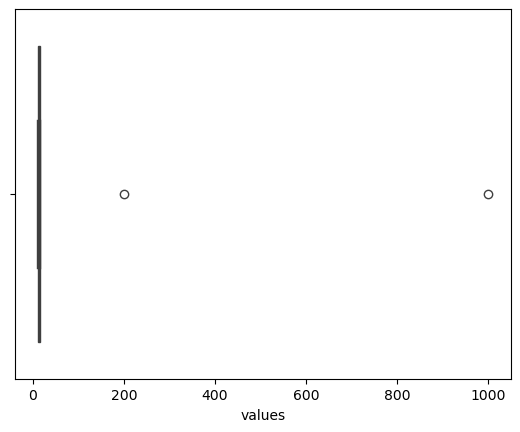

In [59]:
sns.boxplot(x="values",data=df)

In [60]:
df["zscore"]=(df["values"]-df.values.mean())/df["values"].std()##std

In [61]:
df["zscore"]

0   -0.387697
1   -0.381268
2   -0.381268
3   -0.378053
4   -0.374838
5   -0.374838
6   -0.371624
7   -0.368409
8    2.794893
9    0.223103
Name: zscore, dtype: float64

In [62]:
import numpy as np

In [63]:
out=0.9
outlaiers=df[abs(df["zscore"])>out]

In [64]:
outlaiers

,values,zscore
8,1000,2.794893


# IQR

In [65]:
import pandas as pd

In [66]:
df=pd.DataFrame({"values":[10,12,12,13,14,14,15,16,1000,200]})

In [67]:
df

,values
0,10
1,12
2,12
3,13
4,14
5,14
6,15
7,16
8,1000
9,200


In [68]:
Q1=df["values"].quantile(0.25)
Q3=df["values"].quantile(0.75)
IQR=Q3-Q1

In [69]:
IQR

np.float64(3.5)

In [70]:
outlierss=df[(df["values"]<Q1-1.5*IQR)|(df["values"]>Q3+1.5*IQR)]

In [71]:
outlierss

,values
8,1000
9,200


In [72]:
Q1=df["values"].quantile(0.25)
Q3=df["values"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR


In [73]:
df_clean=df[(df["values"]>=lower_bound)&(df["values"]<=upper_bound)]

In [74]:
df_clean

,values
0,10
1,12
2,12
3,13
4,14
5,14
6,15
7,16


<Axes: xlabel='values'>

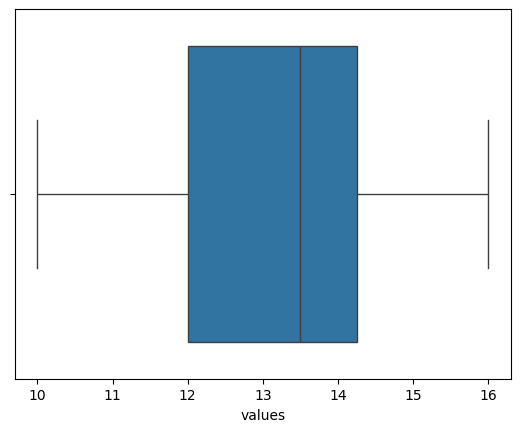

In [75]:
sns.boxplot(x="values",data=df_clean)

# encoding

In [76]:
data=pd.DataFrame({"temp":["hot","cold","very hot","cold","hot"]})

In [77]:
data.temp.unique()

array(['hot', 'cold', 'very hot'], dtype=object)

In [78]:
temp_values=({
    "cold":1,
    "warm":2,
    "hot":3,
    "very hot":4
})
             

In [79]:
temp_values

{'cold': 1, 'warm': 2, 'hot': 3, 'very hot': 4}

In [80]:
df["temp_encoding"]=data.temp.map(temp_values)

In [81]:
data

,temp
0,hot
1,cold
2,very hot
3,cold
4,hot


In [82]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [83]:
import category_encoders as ce

In [84]:
# call
ordinal_encoder=ce.OrdinalEncoder(cols="temp",return_df=True,
                                  mapping=[{
                                      "col":"temp",
                              'mapping':{"cold":1
                                             ,"warm":2,
                                             "hot":3,
                                              "very hot":4}}])

In [85]:
# use
data.temp=ordinal_encoder.fit_transform(data)

In [86]:
data

,temp
0,3
1,1
2,4
3,1
4,3


In [87]:
from sklearn.preprocessing import OrdinalEncoder# many cols

In [88]:
data=pd.DataFrame({"temp":["hot","cold","very hot","cold","hot"]})

In [89]:
# call
encoder=OrdinalEncoder()

In [90]:
#use
data["temp_enc"]=encoder.fit_transform(data)

In [91]:
data

,temp,temp_enc
0,hot,1.0
1,cold,0.0
2,very hot,2.0
3,cold,0.0
4,hot,1.0


In [92]:
data=pd.DataFrame({"temp":["hot","cold","very hot","warm","cold","hot"]})

In [93]:
# call
encoder=OrdinalEncoder(categories=[["hot","cold","very hot","warm"]])

In [94]:
#use
data["temp_enc"]=encoder.fit_transform(data)

In [95]:
data

,temp,temp_enc
0,hot,0.0
1,cold,1.0
2,very hot,2.0
3,warm,3.0
4,cold,1.0
5,hot,0.0


In [96]:
df=pd.read_csv("50_Startups.csv")

In [97]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [98]:
from sklearn.preprocessing import LabelEncoder

In [99]:
#call
label_encoder=LabelEncoder()

In [100]:
df.State=label_encoder.fit_transform(df.State)

In [101]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,2,192261.83
1,162597.70,151377.59,443898.53,0,191792.06
2,153441.51,101145.55,407934.54,1,191050.39
3,144372.41,118671.85,383199.62,2,182901.99
4,142107.34,91391.77,366168.42,1,166187.94


In [102]:
from sklearn.preprocessing import OneHotEncoder

In [103]:
#call
OHE=OneHotEncoder(drop="first")



In [104]:
# use
enc=pd.DataFrame(OHE.fit_transform(df[["State"]]).toarray())

In [105]:
enc.head()

,0,1
0,0.0,1.0
1,0.0,0.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0


## scaling

In [106]:
data=pd.DataFrame({"age":[21,30,None,69,65,None,35],
                  "BLOOD_PRESS":[120,130,110,None,80,145,None],
                   "colestrol":[210,None,300,210,None,200,400]
                  })

In [107]:
data


,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,NaN,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,NaN
5,NaN,145.0,200.0
6,35.0,NaN,400.0


# handle nulls

In [108]:


data.age.fillna(data.age.mean(),inplace=True)


In [109]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,44.0,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,NaN
5,44.0,145.0,200.0
6,35.0,NaN,400.0


In [110]:
data.BLOOD_PRESS.fillna(data.BLOOD_PRESS.mean(),inplace=True)

In [111]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,44.0,110.0,300.0
3,69.0,117.0,210.0
4,65.0,80.0,NaN
5,44.0,145.0,200.0
6,35.0,117.0,400.0


In [112]:
data.colestrol.fillna(data.colestrol.mean(),inplace=True)

In [113]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,264.0
2,44.0,110.0,300.0
3,69.0,117.0,210.0
4,65.0,80.0,264.0
5,44.0,145.0,200.0
6,35.0,117.0,400.0


In [114]:
data.isnull().sum()

age            0
BLOOD_PRESS    0
colestrol      0
dtype: int64

# another way to hanle

In [115]:
from sklearn.impute import SimpleImputer

In [116]:
data=pd.DataFrame({"age":[21,30,None,69,65,None,35],
                  "BLOOD_PRESS":[120,130,110,None,80,145,None],
                   "colestrol":[210,None,300,210,None,200,400]
                  })

In [117]:
data

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,NaN
2,NaN,110.0,300.0
3,69.0,NaN,210.0
4,65.0,80.0,NaN
5,NaN,145.0,200.0
6,35.0,NaN,400.0


In [118]:
#call
imputer=SimpleImputer(strategy="mean")

In [119]:
# fit transform
data_imputed=imputer.fit_transform(data)

In [120]:
data_imputed

array([[ 21., 120., 210.],
       [ 30., 130., 264.],
       [ 44., 110., 300.],
       [ 69., 117., 210.],
       [ 65.,  80., 264.],
       [ 44., 145., 200.],
       [ 35., 117., 400.]])

In [121]:
data_imp=pd.DataFrame(data_imputed,columns=data.columns)

In [122]:
data_imp

,age,BLOOD_PRESS,colestrol
0,21.0,120.0,210.0
1,30.0,130.0,264.0
2,44.0,110.0,300.0
3,69.0,117.0,210.0
4,65.0,80.0,264.0
5,44.0,145.0,200.0
6,35.0,117.0,400.0


# feature scaling

# standarization

In [123]:

from sklearn.preprocessing import StandardScaler

In [124]:
#call
scaler =StandardScaler()

In [125]:
# use
data_scaled=scaler.fit_transform(data_imp)

In [126]:
data_scaled

array([[-1.40644882,  0.16269784, -0.82874015],
       [-0.85609928,  0.70502399,  0.        ],
       [ 0.        , -0.3796283 ,  0.55249343],
       [ 1.52874872,  0.        , -0.82874015],
       [ 1.28414892, -2.00660673,  0.        ],
       [ 0.        ,  1.5185132 , -0.98221054],
       [-0.55034954,  0.        ,  2.0871974 ]])

In [127]:
pd.DataFrame(data_scaled)

,0,1,2
0,-1.406449,0.162698,-0.828740
1,-0.856099,0.705024,0.000000
2,0.000000,-0.379628,0.552493
3,1.528749,0.000000,-0.828740
4,1.284149,-2.006607,0.000000
5,0.000000,1.518513,-0.982211
6,-0.550350,0.000000,2.087197


In [128]:
scaler.inverse_transform(data_scaled)

array([[ 21., 120., 210.],
       [ 30., 130., 264.],
       [ 44., 110., 300.],
       [ 69., 117., 210.],
       [ 65.,  80., 264.],
       [ 44., 145., 200.],
       [ 35., 117., 400.]])

# normalization  maxminscaler 

In [129]:
from sklearn.preprocessing import MinMaxScaler# from 0 to 1

In [130]:
MMscaler =MinMaxScaler()

In [131]:
data_scaled=MMscaler.fit_transform(data_imp)

In [132]:
data_scaled

array([[0.        , 0.61538462, 0.05      ],
       [0.1875    , 0.76923077, 0.32      ],
       [0.47916667, 0.46153846, 0.5       ],
       [1.        , 0.56923077, 0.05      ],
       [0.91666667, 0.        , 0.32      ],
       [0.47916667, 1.        , 0.        ],
       [0.29166667, 0.56923077, 1.        ]])

# robust scaler

In [133]:
from sklearn.preprocessing import RobustScaler

In [134]:
rscaler =RobustScaler()

In [135]:
data_scaled=rscaler.fit_transform(data_imp)

In [136]:
data_scaled

array([[-1.04545455,  0.26086957, -0.75      ],
       [-0.63636364,  1.13043478,  0.        ],
       [ 0.        , -0.60869565,  0.5       ],
       [ 1.13636364,  0.        , -0.75      ],
       [ 0.95454545, -3.2173913 ,  0.        ],
       [ 0.        ,  2.43478261, -0.88888889],
       [-0.40909091,  0.        ,  1.88888889]])

In [137]:
df=pd.read_csv("aug_train (1).csv")

In [138]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,17163,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,32023,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,87447,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,501933,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0


In [139]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000
mean,234392.953477,38.545691,0.998108,26.406867,0.489182,30711.271362,111.939812,154.189429,0.163811
std,139527.487326,15.226897,0.043455,13.181241,0.499884,17061.595532,54.286511,83.735107,0.370104
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,115006.250000,25.000000,1.000000,15.000000,0.000000,24546.000000,26.000000,81.000000,0.000000
50%,230461.500000,36.000000,1.000000,28.000000,0.000000,31692.000000,145.000000,154.000000,0.000000
75%,345434.750000,49.000000,1.000000,35.000000,1.000000,39447.750000,152.000000,227.000000,0.000000
max,508145.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382154 entries, 0 to 382153
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    382154 non-null  int64  
 1   Gender                382154 non-null  object 
 2   Age                   382154 non-null  int64  
 3   Driving_License       382154 non-null  int64  
 4   Region_Code           382154 non-null  float64
 5   Previously_Insured    382154 non-null  int64  
 6   Vehicle_Age           382154 non-null  object 
 7   Vehicle_Damage        382154 non-null  object 
 8   Annual_Premium        382154 non-null  float64
 9   Policy_Sales_Channel  382154 non-null  float64
 10  Vintage               382154 non-null  int64  
 11  Response              382154 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 35.0+ MB


## EDA=>exploratory data analysis

In [141]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [142]:
#df.drop_duplicates(inplace=True)

In [143]:
df.Response.value_counts()

Response
0    319553
1     62601
Name: count, dtype: int64

In [144]:
import matplotlib.pyplot as plt

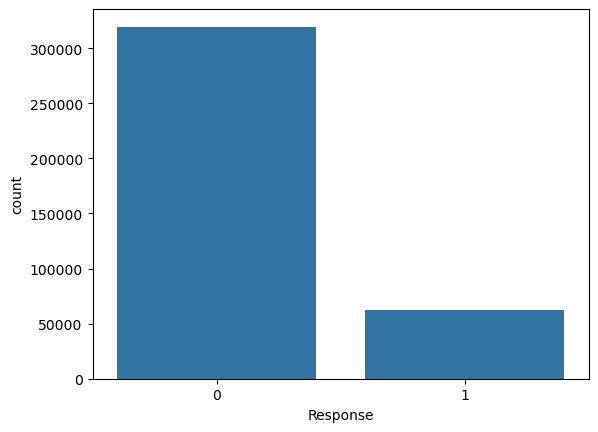

In [145]:
sns.countplot(x="Response",data=df)
plt.show()

In [146]:
df.drop(columns=["id"],inplace=True)

In [147]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0
...,...,...,...,...,...,...,...,...,...,...,...
382149,Male,24,1,15.0,0,< 1 Year,Yes,23938.0,152.0,105,0
382150,Male,27,1,28.0,1,< 1 Year,No,336395.0,152.0,144,0
382151,Male,45,1,28.0,0,1-2 Year,Yes,40443.0,26.0,187,0
382152,Female,28,1,28.0,1,< 1 Year,No,25380.0,152.0,208,0


In [148]:
df.drop_duplicates(inplace=True)

In [149]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0
...,...,...,...,...,...,...,...,...,...,...,...
382149,Male,24,1,15.0,0,< 1 Year,Yes,23938.0,152.0,105,0
382150,Male,27,1,28.0,1,< 1 Year,No,336395.0,152.0,144,0
382151,Male,45,1,28.0,0,1-2 Year,Yes,40443.0,26.0,187,0
382152,Female,28,1,28.0,1,< 1 Year,No,25380.0,152.0,208,0


In [150]:
df.duplicated().sum()

np.int64(0)

In [151]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0
...,...,...,...,...,...,...,...,...,...,...,...
382149,Male,24,1,15.0,0,< 1 Year,Yes,23938.0,152.0,105,0
382150,Male,27,1,28.0,1,< 1 Year,No,336395.0,152.0,144,0
382151,Male,45,1,28.0,0,1-2 Year,Yes,40443.0,26.0,187,0
382152,Female,28,1,28.0,1,< 1 Year,No,25380.0,152.0,208,0


# data splitting

In [155]:
x=df.drop(columns="Response")
y=df.Response

In [156]:
x.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,1,22,1,7.0,1,1,0,2630.0,152.0,16
1,1,42,1,28.0,0,0,1,43327.0,26.0,135
2,0,66,1,33.0,0,0,1,35841.0,124.0,253
3,0,22,1,33.0,0,1,0,27645.0,152.0,69
4,1,28,1,46.0,1,1,0,29023.0,152.0,211


In [157]:
y

0         0
1         0
2         0
3         0
4         0
         ..
382149    0
382150    0
382151    0
382152    0
382153    0
Name: Response, Length: 381868, dtype: int64

In [187]:
from sklearn.model_selection import train_test_split# divide to x,y (train->80 & tes->20t)

In [189]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)# not change data & not include certain num

In [190]:
x_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
54515,1,28,1,35.0,1,1,0,2630.0,152.0,143
152430,1,28,1,2.0,1,1,0,35153.0,152.0,13
259828,0,22,1,37.0,0,1,1,20297.0,152.0,37
242176,0,22,1,35.0,1,1,1,2630.0,152.0,284
211221,1,52,1,8.0,0,0,1,54406.0,7.0,21


In [191]:
x_train.shape

(305494, 10)

In [192]:
y_train.shape

(305494,)

In [193]:
x_test.shape

(76374, 10)

In [176]:
y_test.shape

(76374,)

# handle categorical(features)

In [152]:
# call
le= LabelEncoder()

In [183]:
#use
x_train.Gender=le.fit_transform(x_train.Gender)


In [182]:
#x_test.Gender=le.transform(x_test.Gender)

In [184]:
x_train.Vehicle_Age=le.fit_transform(x_train.Vehicle_Age)
x_train.Vehicle_Damage=le.fit_transform(x_train.Vehicle_Damage)

In [154]:
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,22,1,7.0,1,1,0,2630.0,152.0,16,0
1,1,42,1,28.0,0,0,1,43327.0,26.0,135,0
2,0,66,1,33.0,0,0,1,35841.0,124.0,253,0
3,0,22,1,33.0,0,1,0,27645.0,152.0,69,0
4,1,28,1,46.0,1,1,0,29023.0,152.0,211,0


# handle numerical

### scaling

In [194]:
from sklearn.preprocessing import StandardScaler

In [195]:
scaler =StandardScaler()

In [197]:
data_scaled=scaler.fit_transform(x_train)

### imbalance

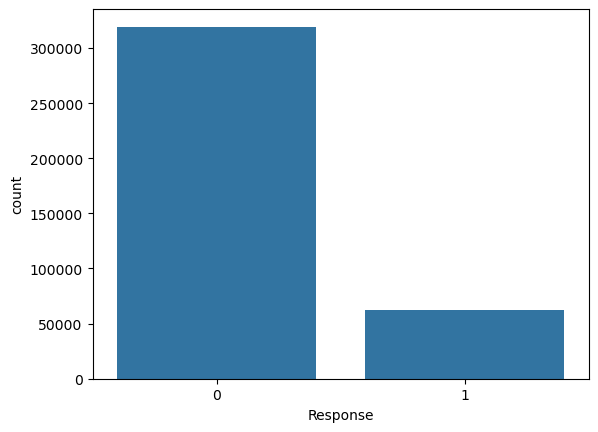

In [199]:
sns.countplot(x="Response",data=df)
plt.show()

### over sampling

#### random over sampling->duplicate

In [200]:
from imblearn.over_sampling import RandomOverSampler #increase

In [203]:
#call
ROS=RandomOverSampler(sampling_strategy="minority")

In [206]:
x_sample,y_sample=ROS.fit_resample(x_train,y_train)

before oversample
Response
0    255320
1     50174
Name: count, dtype: int64


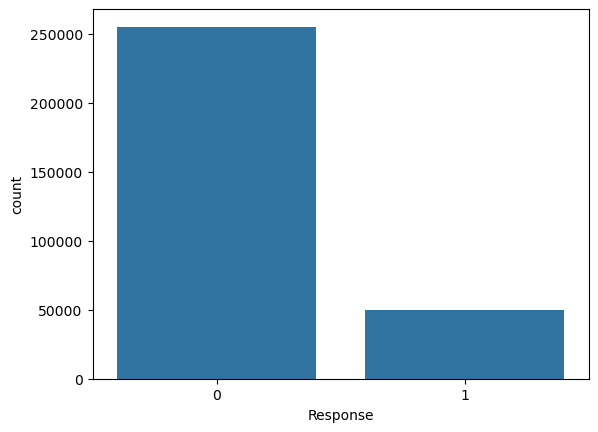

after oversample
Response
0    255320
1    255320
Name: count, dtype: int64


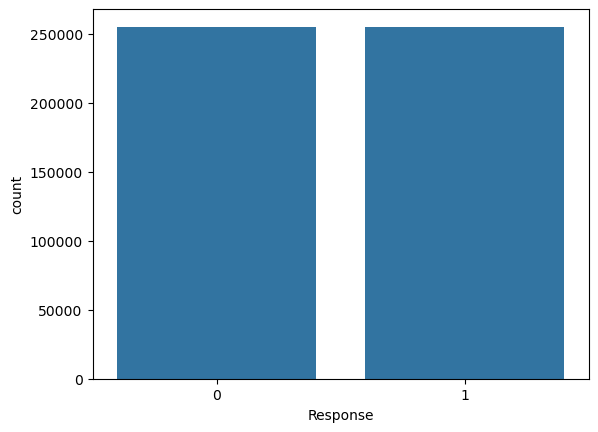

In [215]:
print("before oversample")
print(y_train.value_counts())
sns.countplot(x=y_train)
plt.show()
print("after oversample")

print(y_sample.value_counts())
sns.countplot(x=y_sample)
plt.show()

#### smote ->synthetic data

In [217]:
from imblearn.over_sampling import SMOTE

In [218]:
sm=SMOTE()

In [220]:
x_smote,y_smote=sm.fit_resample(x_train,y_train)

before oversample
Response
0    255320
1     50174
Name: count, dtype: int64


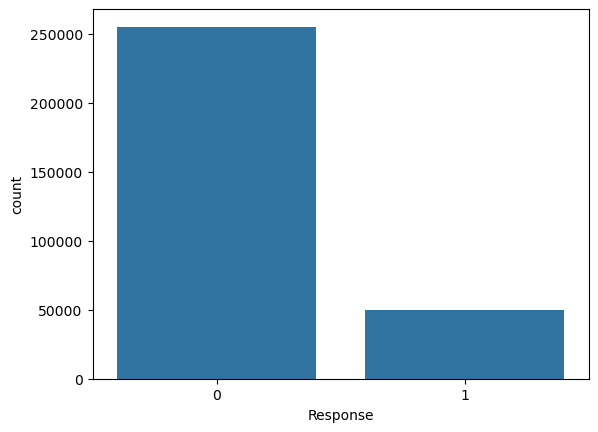

after oversample
Response
0    255320
1    255320
Name: count, dtype: int64


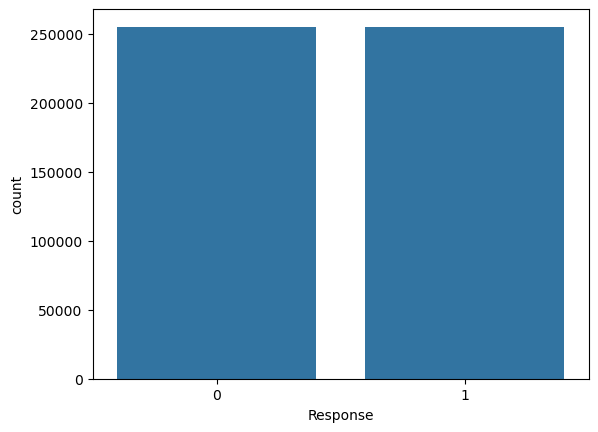

In [221]:
print("before oversample")
print(y_train.value_counts())
sns.countplot(x=y_train)
plt.show()
print("after oversample")

print(y_sample.value_counts())
sns.countplot(x=y_smote)
plt.show()

#### under sampling

###### randomundersampling->magirity

In [229]:
from imblearn.under_sampling import RandomUnderSampler# decrease

In [232]:
RUS=RandomUnderSampler(sampling_strategy="majority")

In [233]:
x_sample,y_sample=RUS.fit_resample(x_train,y_train)

before oversample
Response
0    255320
1     50174
Name: count, dtype: int64


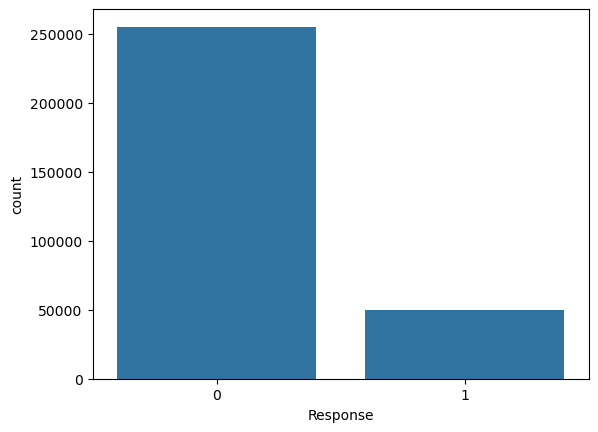

after oversample
Response
0    50174
1    50174
Name: count, dtype: int64


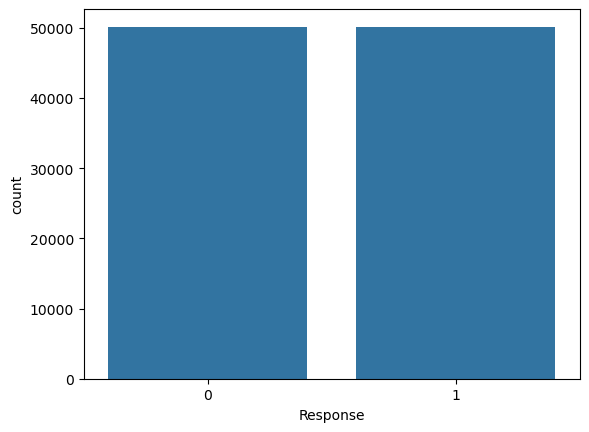

In [234]:
print("before oversample")
print(y_train.value_counts())
sns.countplot(x=y_train)
plt.show()
print("after oversample")

print(y_sample.value_counts())
sns.countplot(x=y_sample)
plt.show()